# ML-Based Prediction of PD-1/PD-L1 Bioactivity
## A Publication-Ready Pipeline with Modern Machine Learning, Dual Validation, and Full Consistency Analysis

**Objective:** Build and rigorously benchmark binary classifiers that predict whether a small molecule is active (IC50 <= 1000 nM) or inactive (IC50 > 1000 nM) against the PD-1/PD-L1 immune checkpoint pathway, using pooled ChEMBL bioactivity data from three related targets, Morgan fingerprints, and physicochemical descriptors.

**Key design decisions:**
- **Pooled targets:** Data from PD-L1 (single protein), PD-1/PD-L1 complex, and PD-L1/2 family are combined to maximize chemical diversity and dataset size (4,400 compounds)
- **Threshold:** Active = IC50 <= 1000 nM, Inactive = IC50 > 1000 nM (intermediates included as inactive for a more balanced and clinically meaningful binary task)
- **Dual validation:** Scaffold-based split (headline) + repeated stratified k-fold (stability)
- **10 models:** Random Forest, Extra Trees, Gradient Boosting, AdaBoost, KNN, SVM, XGBoost, LightGBM, MLP, and a Stacking Ensemble
- **No SMOTE on binary fingerprints** -- class weights used instead
- **Full consistency analysis:** Pairwise Cohen's kappa, Friedman test, Nemenyi post-hoc, CD diagram
- **Validation package:** Y-scrambling, permutation test, SHAP, k-NN Tanimoto applicability domain, ADMET, scaffold diversity


## 1. Environment Setup

Configuration Notice: This notebook uses :
> - RandomizedSearchCV: 10 iterations (full: 20)
> - Repeated CV: 2x5 = 10 folds (full: 5x5 = 25)
> - Permutation test: 50 iterations (full: 200)
> - Y-scrambling: 10 shuffles (full: 20)
> - n_estimators cap: 200 (full: 300)
>
> Contains 9 models + stacking ensemble


In [ ]:
# Install required packages (Colab)
!pip install -q rdkit xgboost lightgbm shap chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 2.4 MB/s eta 0:00:00


In [ ]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import time
import pickle

# RDKit
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, Lipinski, rdMolDescriptors, QED
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize
RDLogger.DisableLog("rdApp.*")

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    RandomizedSearchCV
)
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    cohen_kappa_score, balanced_accuracy_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance
from sklearn.base import clone

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# SHAP
import shap

# Statistics
from scipy.stats import mannwhitneyu, friedmanchisquare, studentized_range
from scipy.stats import randint, uniform, loguniform

# ChEMBL
from chembl_webresource_client.new_client import new_client

# Plotting config
plt.rcParams["font.family"] = ["Liberation Sans", "Arimo", "DejaVu Sans"]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
sns.set_style("whitegrid")
sns.set_palette("colorblind")

print("All imports successful.")


All imports successful.


In [ ]:
# Global configuration
RANDOM_STATE = 42
N_BITS = 2048
RADIUS = 2
ACTIVE_THRESHOLD = 1000     # IC50 <= 1000 nM -> active
CV_REPEATS = 2              # Repeated stratified k-fold repeats
CV_FOLDS = 5                # Folds per repeat
N_SEARCH_ITER = 10          # RandomizedSearchCV iterations per model
N_PERMUTATIONS = 50        # Permutation test iterations
N_SCRAMBLES = 10            # Y-scrambling shuffles

# Target IDs to pool (all PD-1/PD-L1 pathway)
TARGET_IDS = {
    "CHEMBL3580522": "PD-L1 (single protein, human)",
    "CHEMBL4523993": "PD-1/PD-L1 complex (human)",
    "CHEMBL6066575": "PD-L1/2 family (protein family)",
}

np.random.seed(RANDOM_STATE)


## 2. Data Acquisition from ChEMBL (Pooled Targets)

Data is pooled from three related targets in the PD-1/PD-L1 immune checkpoint pathway:
- **CHEMBL3580522** -- PD-L1 single protein
- **CHEMBL4523993** -- PD-1/PD-L1 protein complex
- **CHEMBL6066575** -- PD-L1/2 protein family

This maximizes chemical diversity and dataset size. The source target is tracked for each compound.


In [ ]:
# Retrieve IC50 activities from all targets
activity_client = new_client.activity
all_activities = []

for tid, tname in TARGET_IDS.items():
    print(f"Fetching {tid} ({tname})...")
    res = activity_client.filter(target_chembl_id=tid, standard_type="IC50", standard_relation="=")
    df_t = pd.DataFrame.from_dict(res)
    df_t["source_target_id"] = tid
    df_t["source_target_name"] = tname
    all_activities.append(df_t)
    print(f"  Retrieved {len(df_t)} activities")

df_raw = pd.concat(all_activities, ignore_index=True)
print(f"\nTotal raw activities: {len(df_raw)}")


Fetching CHEMBL3580522 (PD-L1 (single protein, human))...
  Retrieved 972 activities
Fetching CHEMBL4523993 (PD-1/PD-L1 complex (human))...
  Retrieved 4233 activities
Fetching CHEMBL6066575 (PD-L1/2 family (protein family))...
  Retrieved 432 activities

Total raw activities: 5637


In [ ]:
# Keep only essential columns and filter
cols_needed = ["molecule_chembl_id", "canonical_smiles", "standard_value",
               "standard_units", "source_target_id", "source_target_name"]
df = df_raw[cols_needed].copy()

# Filter to nM units only
df = df[df["standard_units"] == "nM"]

# Convert standard_value to numeric
df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")

# Drop rows with missing SMILES or IC50
df.dropna(subset=["canonical_smiles", "standard_value"], inplace=True)

# Strip whitespace
df["canonical_smiles"] = df["canonical_smiles"].str.strip()

# Remove invalid SMILES (RDKit parse check)
valid_smiles = []
for smi in df["canonical_smiles"]:
    mol = Chem.MolFromSmiles(smi)
    valid_smiles.append(mol is not None)
df = df[valid_smiles].copy()

print(f"After filtering: {len(df)} activity records")
print(f"Unique molecule_chembl_id: {df['molecule_chembl_id'].nunique()}")


After filtering: 5629 activity records
Unique molecule_chembl_id: 4399


In [ ]:
# Deduplicate by molecule_chembl_id across all targets
# If a compound appears in multiple targets, keep the median IC50
# and record all source targets
df = df.groupby("molecule_chembl_id").agg({
    "canonical_smiles": "first",
    "standard_value": "median",
    "source_target_id": lambda x: ",".join(sorted(set(x))),
    "source_target_name": lambda x: "; ".join(sorted(set(x))),
}).reset_index()

print(f"After deduplication: {len(df)} unique compounds")

# Show source target distribution
print("\nSource target distribution:")
for tid, tname in TARGET_IDS.items():
    count = df["source_target_id"].str.contains(tid).sum()
    print(f"  {tid} ({tname}): {count} compounds")
multi_target = df["source_target_id"].str.contains(",").sum()
print(f"  Compounds in multiple targets: {multi_target}")


After deduplication: 4399 unique compounds

Source target distribution:
  CHEMBL3580522 (PD-L1 (single protein, human)): 739 compounds
  CHEMBL4523993 (PD-1/PD-L1 complex (human)): 3256 compounds
  CHEMBL6066575 (PD-L1/2 family (protein family)): 427 compounds
  Compounds in multiple targets: 23


## 3. Data Curation & Labeling

**Binary classification scheme:**
- **Active** (label = 1): IC50 <= 1000 nM
- **Inactive** (label = 0): IC50 > 1000 nM

This includes intermediate-potency compounds (1000-10000 nM) as inactive, producing a more balanced dataset and a more clinically meaningful binary task. The 1000 nM cutoff is a standard potency threshold in medicinal chemistry.


In [ ]:
# Apply binary classification: active <= 1000 nM, inactive > 1000 nM
df["activity"] = (df["standard_value"] <= ACTIVE_THRESHOLD).astype(int)
df["class"] = df["activity"].map({1: "active", 0: "inactive"})

print(f"Final dataset: {len(df)} compounds")
print(f"Active (IC50 <= 1000 nM): {(df['activity'] == 1).sum()} ({df['activity'].mean():.1%})")
print(f"Inactive (IC50 > 1000 nM):  {(df['activity'] == 0).sum()} ({(1 - df['activity'].mean()):.1%})")


Final dataset: 4399 compounds
Active (IC50 <= 1000 nM): 3603 (81.9%)
Inactive (IC50 > 1000 nM):  796 (18.1%)


In [ ]:
# SMILES standardization: largest fragment, neutralize, canonicalize
def standardize_smiles(smi):
    """Standardize a SMILES string: largest fragment, neutralize charges, canonicalize."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
    mol = rdMolStandardize.Uncharger().uncharge(mol)
    return Chem.MolToSmiles(mol)

tqdm.pandas(desc="Standardizing SMILES")
df["canonical_smiles"] = df["canonical_smiles"].progress_apply(standardize_smiles)
df = df[df["canonical_smiles"].notna()].copy()
print(f"After standardization: {len(df)} compounds")


Standardizing SMILES:   0%|          | 0/4399 [00:00<?, ?it/s]

After standardization: 4399 compounds


In [ ]:
# Compute Bemis-Murcko scaffolds
def get_scaffold(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

tqdm.pandas(desc="Computing scaffolds")
df["scaffold"] = df["canonical_smiles"].progress_apply(get_scaffold)
df = df[df["scaffold"].notna()].copy()

n_scaffolds = df["scaffold"].nunique()
print(f"Unique scaffolds: {n_scaffolds}")
print(f"Dataset: {len(df)} compounds, {n_scaffolds} scaffolds")
print(f"Active: {(df['activity'] == 1).sum()}, Inactive: {(df['activity'] == 0).sum()}")


Computing scaffolds:   0%|          | 0/4399 [00:00<?, ?it/s]

Unique scaffolds: 1700
Dataset: 4399 compounds, 1700 scaffolds
Active: 3603, Inactive: 796


In [ ]:
# Convert IC50 to pIC50 for EDA
def ic50_to_pic50(ic50_nM):
    ic50_capped = min(ic50_nM, 1e8)
    return -np.log10(ic50_capped * 1e-9)

df["pIC50"] = df["standard_value"].apply(ic50_to_pic50)

# Dataset composition table
print("Dataset composition:")
print(f"  Total compounds: {len(df)}")
print(f"  Active (IC50 <= 1000 nM): {(df['activity'] == 1).sum()}")
print(f"  Inactive (IC50 > 1000 nM): {(df['activity'] == 0).sum()}")
print(f"  Unique scaffolds: {n_scaffolds}")
print(f"  Class balance: {df['activity'].mean():.1%} active")
print(f"  IC50 range: {df['standard_value'].min():.1f} - {df['standard_value'].max():.1f} nM")
print(f"  pIC50 range: {df['pIC50'].min():.2f} - {df['pIC50'].max():.2f}")
df.head()


Dataset composition:
  Total compounds: 4399
  Active (IC50 <= 1000 nM): 3603
  Inactive (IC50 > 1000 nM): 796
  Unique scaffolds: 1700
  Class balance: 81.9% active
  IC50 range: 0.0 - 5000000.0 nM
  pIC50 range: 2.30 - 13.10


,molecule_chembl_id,canonical_smiles,standard_value,source_target_id,source_target_name,activity,class,scaffold,pIC50
0,CHEMBL1201303,Cc1cc(/C=C/c2ccc3cc(N(C)C)ccc3[n+]2C)c(C)n1-c1...,15014.83,CHEMBL4523993,PD-1/PD-L1 complex (human),0,inactive,C(=Cc1ccc2ccccc2[nH+]1)c1ccn(-c2ccccc2)c1,4.823480
1,CHEMBL1516633,O=C(NCCN1CCOCC1)c1ccc(-c2ccccc2)cc1,1544.00,CHEMBL3580522,"PD-L1 (single protein, human)",0,inactive,O=C(NCCN1CCOCC1)c1ccc(-c2ccccc2)cc1,5.811353
2,CHEMBL1630488,COc1ccc(Nc2nnc(-c3ccc([N+](=O)[O-])cc3)o2)cc1,64110.00,CHEMBL4523993,PD-1/PD-L1 complex (human),0,inactive,c1ccc(Nc2nnc(-c3ccccc3)o2)cc1,4.193074
3,CHEMBL1974418,Cc1nc(C)c(C(=O)NNC(=O)Cc2ccccc2)cc1C(=O)NNC(=O...,1.09,CHEMBL4523993,PD-1/PD-L1 complex (human),1,active,O=C(Cc1ccccc1)NNC(=O)c1cncc(C(=O)NNC(=O)Cc2ccc...,8.962574
4,CHEMBL1998137,COc1ccc(-c2nc(N)nc(-c3cc(C)ccc3O)c2Cl)cc1,2.44,CHEMBL4523993,PD-1/PD-L1 complex (human),1,active,c1ccc(-c2cc(-c3ccccc3)ncn2)cc1,8.612610


## 4. Exploratory Data Analysis

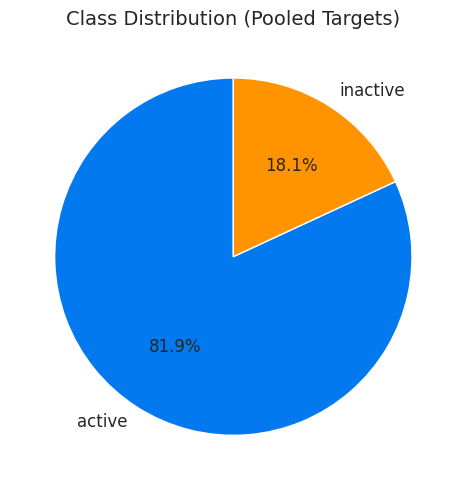

class
active      3603
inactive     796
Name: count, dtype: int64


In [ ]:
# Class distribution
fig, ax = plt.subplots(figsize=(6, 5))
class_counts = df["class"].value_counts()
colors = ["#0279EE", "#FF9400"]
ax.pie(class_counts, labels=class_counts.index, autopct="%1.1f%%",
       colors=colors, startangle=90, textprops={"fontsize": 12})
ax.set_title("Class Distribution (Pooled Targets)", fontsize=14)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(class_counts)


In [ ]:
# Compute Lipinski descriptors for EDA
def compute_lipinski(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append([np.nan] * 4)
            continue
        rows.append([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Lipinski.NumHDonors(mol),
            Lipinski.NumHAcceptors(mol),
        ])
    return pd.DataFrame(rows, columns=["MW", "LogP", "NumHDonors", "NumHAcceptors"])

lipinski_df = compute_lipinski(df["canonical_smiles"])
df_eda = pd.concat([df.reset_index(drop=True), lipinski_df.reset_index(drop=True)], axis=1)
df_eda.head()


,molecule_chembl_id,canonical_smiles,standard_value,source_target_id,source_target_name,activity,class,scaffold,pIC50,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL1201303,Cc1cc(/C=C/c2ccc3cc(N(C)C)ccc3[n+]2C)c(C)n1-c1...,15014.83,CHEMBL4523993,PD-1/PD-L1 complex (human),0,inactive,C(=Cc1ccc2ccccc2[nH+]1)c1ccn(-c2ccccc2)c1,4.823480,382.531,5.30824,0,1
1,CHEMBL1516633,O=C(NCCN1CCOCC1)c1ccc(-c2ccccc2)cc1,1544.00,CHEMBL3580522,"PD-L1 (single protein, human)",0,inactive,O=C(NCCN1CCOCC1)c1ccc(-c2ccccc2)cc1,5.811353,310.397,2.41560,1,3
2,CHEMBL1630488,COc1ccc(Nc2nnc(-c3ccc([N+](=O)[O-])cc3)o2)cc1,64110.00,CHEMBL4523993,PD-1/PD-L1 complex (human),0,inactive,c1ccc(Nc2nnc(-c3ccccc3)o2)cc1,4.193074,312.285,3.39700,1,7
3,CHEMBL1974418,Cc1nc(C)c(C(=O)NNC(=O)Cc2ccccc2)cc1C(=O)NNC(=O...,1.09,CHEMBL4523993,PD-1/PD-L1 complex (human),1,active,O=C(Cc1ccccc1)NNC(=O)c1cncc(C(=O)NNC(=O)Cc2ccc...,8.962574,459.506,1.70584,4,5
4,CHEMBL1998137,COc1ccc(-c2nc(N)nc(-c3cc(C)ccc3O)c2Cl)cc1,2.44,CHEMBL4523993,PD-1/PD-L1 complex (human),1,active,c1ccc(-c2cc(-c3ccccc3)ncn2)cc1,8.612610,341.798,4.06882,2,5


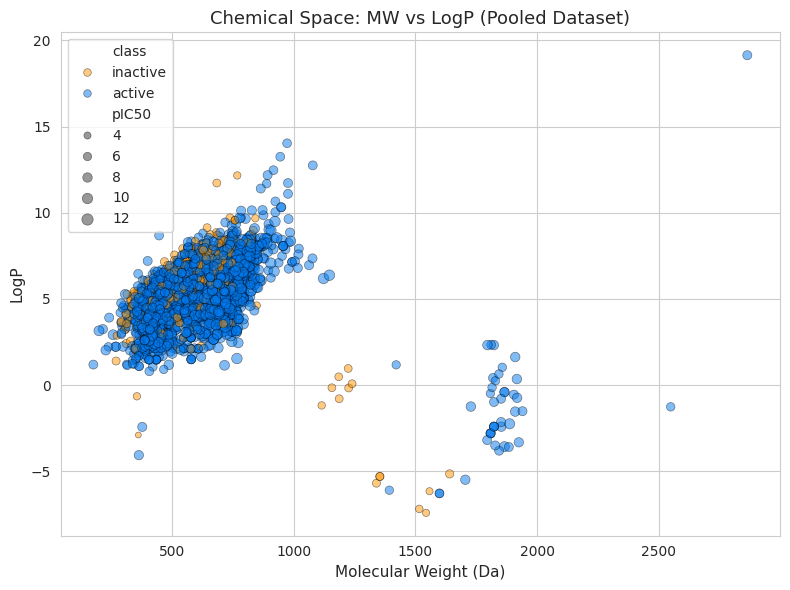

In [ ]:
# MW vs LogP scatter plot colored by class
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df_eda, x="MW", y="LogP", hue="class", size="pIC50",
                palette={"active": "#0279EE", "inactive": "#FF9400"},
                edgecolor="black", alpha=0.5, ax=ax, s=30)
ax.set_title("Chemical Space: MW vs LogP (Pooled Dataset)", fontsize=13)
ax.set_xlabel("Molecular Weight (Da)", fontsize=11)
ax.set_ylabel("LogP", fontsize=11)
plt.tight_layout()
plt.savefig("chemical_space_mw_logp.png", dpi=300, bbox_inches="tight")
plt.show()


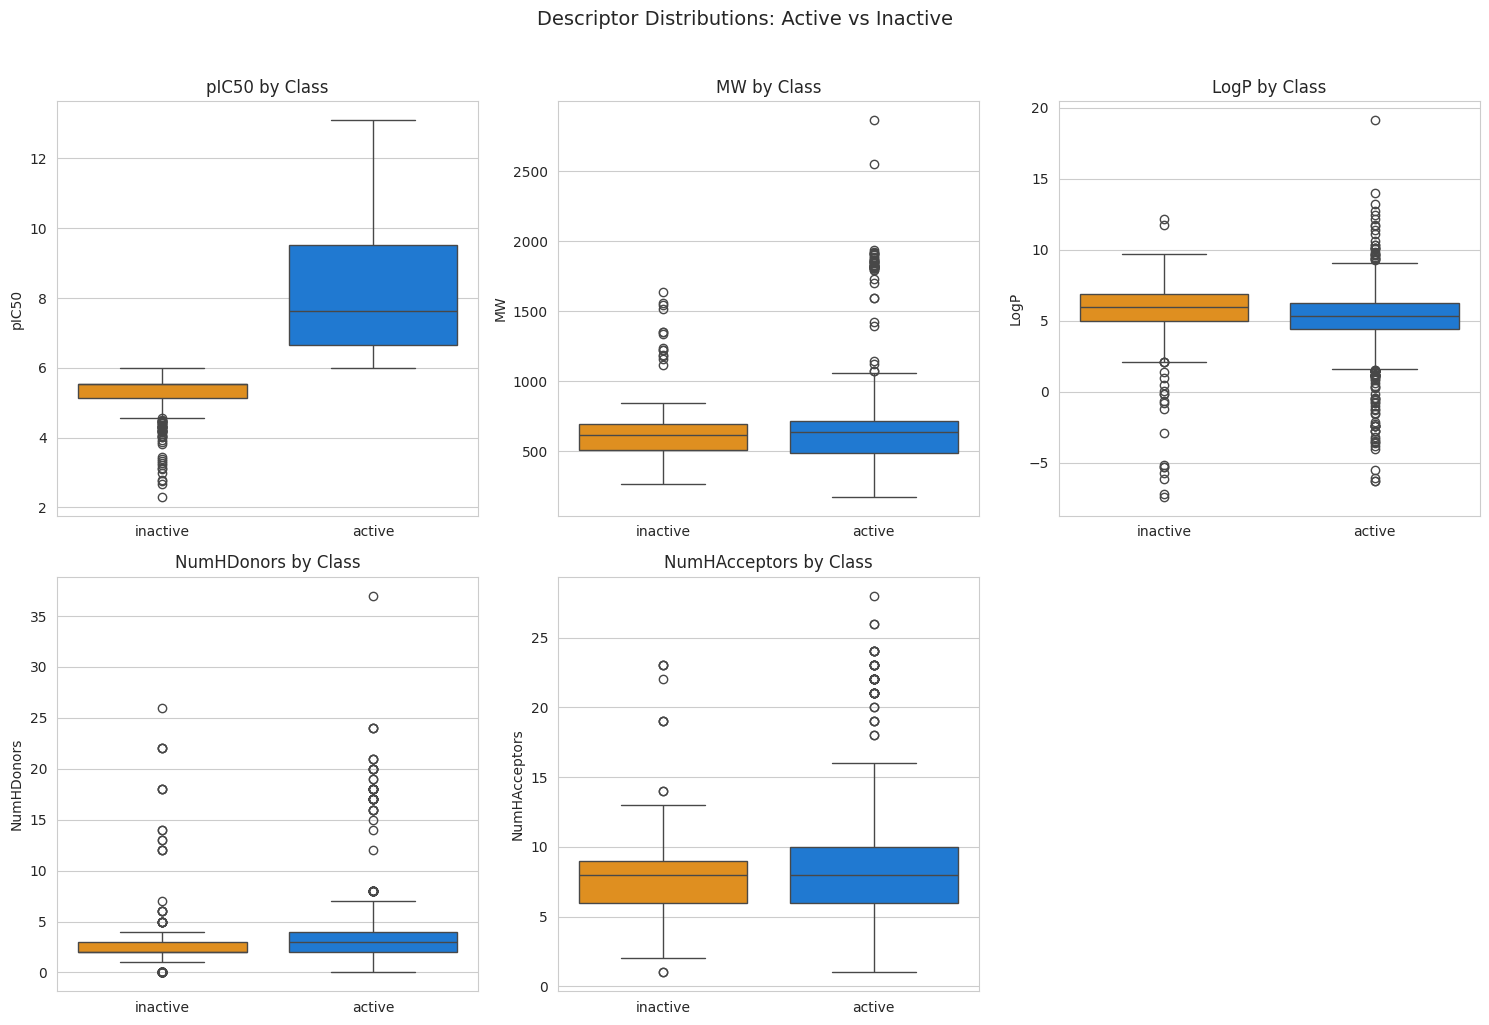

In [ ]:
# Box plots for each descriptor by class
descriptors = ["pIC50", "MW", "LogP", "NumHDonors", "NumHAcceptors"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, desc in enumerate(descriptors):
    sns.boxplot(data=df_eda, x="class", y=desc,
                palette={"active": "#0279EE", "inactive": "#FF9400"}, ax=axes[i])
    axes[i].set_title(f"{desc} by Class", fontsize=12)
    axes[i].set_xlabel("")

axes[-1].axis("off")
plt.suptitle("Descriptor Distributions: Active vs Inactive", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("descriptor_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Mann-Whitney U test for each descriptor
def mannwhitney_test(data, descriptor):
    active = data[data["class"] == "active"][descriptor]
    inactive = data[data["class"] == "inactive"][descriptor]
    stat, p_value = mannwhitneyu(active, inactive, alternative="two-sided")
    return {"Descriptor": descriptor, "Statistic": stat, "p-value": p_value,
            "Significant": "Yes" if p_value < 0.05 else "No"}

results = []
for desc in descriptors:
    results.append(mannwhitney_test(df_eda, desc))

mw_results = pd.DataFrame(results)
print("Mann-Whitney U Test Results:")
print(mw_results.to_string(index=False))


Mann-Whitney U Test Results:
   Descriptor  Statistic      p-value Significant
        pIC50  2867988.0 0.000000e+00         Yes
           MW  1547005.0 4.922585e-04         Yes
         LogP  1111686.0 2.814221e-23         Yes
   NumHDonors  1637185.0 1.265091e-10         Yes
NumHAcceptors  1610444.0 4.038623e-08         Yes


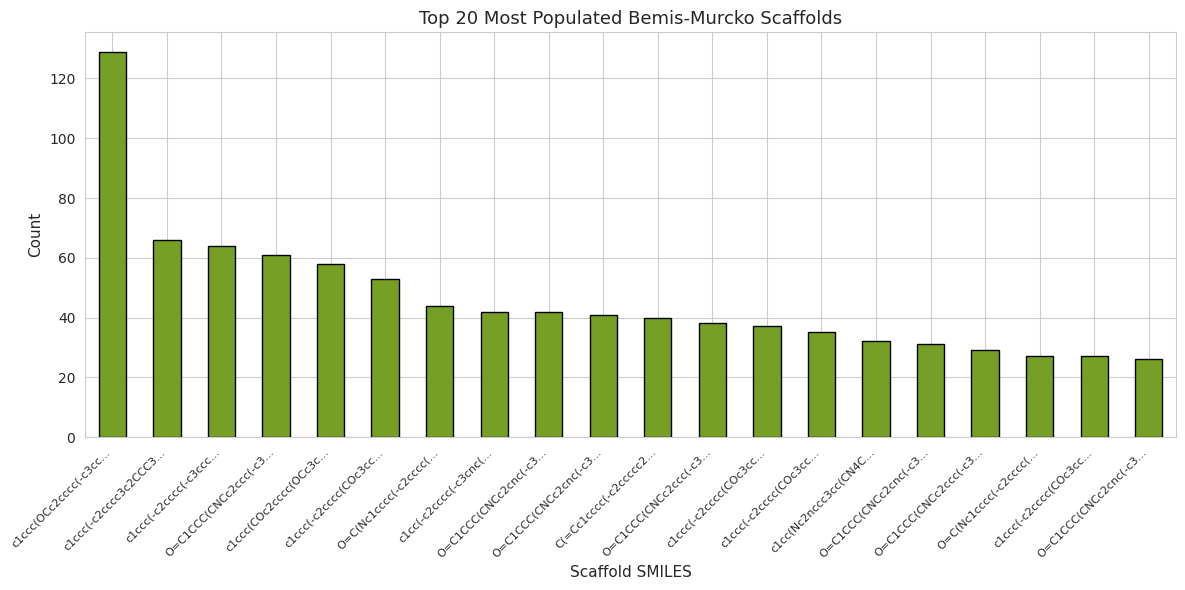

Total unique scaffolds: 1700
Singletons (scaffolds with 1 compound): 1182


In [ ]:
# Scaffold diversity: top-20 most populated scaffolds
top_scaffolds = df["scaffold"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
top_scaffolds.plot(kind="bar", ax=ax, color="#75A025", edgecolor="black")
ax.set_title("Top 20 Most Populated Bemis-Murcko Scaffolds", fontsize=13)
ax.set_xlabel("Scaffold SMILES", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_xticklabels([s[:20] + "..." if len(s) > 20 else s for s in top_scaffolds.index],
                    rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("scaffold_diversity.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Total unique scaffolds: {df['scaffold'].nunique()}")
print(f"Singletons (scaffolds with 1 compound): {(df['scaffold'].value_counts() == 1).sum()}")


## 5. Feature Engineering

**Features:**
- **Morgan fingerprints** (2048 bits, radius 2) -- circular substructural features
- **17 RDKit physicochemical descriptors** -- MW, LogP, TPSA, H-bond donors/acceptors, rotatable bonds, ring counts, QED, etc.

Combined feature matrix: 2048 + 17 = 2065 features.


In [ ]:
# Generate Morgan fingerprints
def generate_morgan_fingerprints(smiles_list, radius=RADIUS, n_bits=N_BITS):
    fps = []
    for smi in tqdm(smiles_list, desc="Generating Morgan fingerprints"):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            fps.append(np.array(fp))
        else:
            fps.append(np.zeros(n_bits, dtype=int))
    cols = [f"FP_{i}" for i in range(n_bits)]
    return pd.DataFrame(np.array(fps), columns=cols)

morgan_df = generate_morgan_fingerprints(df["canonical_smiles"])
print(f"Morgan fingerprints shape: {morgan_df.shape}")


Generating Morgan fingerprints:   0%|          | 0/4399 [00:00<?, ?it/s]

Morgan fingerprints shape: (4399, 2048)


In [ ]:
# Compute physicochemical descriptors
def compute_physchem_descriptors(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append([np.nan] * 17)
            continue
        rows.append([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            Lipinski.NumHDonors(mol),
            Lipinski.NumHAcceptors(mol),
            Descriptors.NumRotatableBonds(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol),
            rdMolDescriptors.CalcNumAliphaticRings(mol),
            rdMolDescriptors.CalcFractionCSP3(mol),
            mol.GetNumHeavyAtoms(),
            rdMolDescriptors.CalcNumRings(mol),
            Descriptors.BalabanJ(mol),
            Descriptors.BertzCT(mol),
            Descriptors.MolMR(mol),
            Descriptors.LabuteASA(mol),
            Descriptors.NumValenceElectrons(mol),
            QED.qed(mol),
        ])
    cols = ["MW", "LogP", "TPSA", "NumHDonors", "NumHAcceptors",
            "NumRotatableBonds", "NumAromaticRings", "NumAliphaticRings",
            "FractionCSP3", "NumHeavyAtoms", "NumRings", "BalabanJ",
            "BertzCT", "MolMR", "LabuteASA", "NumValenceElectrons", "QED"]
    return pd.DataFrame(rows, columns=cols)

physchem_df = compute_physchem_descriptors(df["canonical_smiles"])
print(f"Physicochemical descriptors shape: {physchem_df.shape}")


Physicochemical descriptors shape: (4399, 17)


In [ ]:
# Combine features
X = pd.concat([morgan_df.reset_index(drop=True), physchem_df.reset_index(drop=True)], axis=1)
y = df["activity"].reset_index(drop=True)
scaffolds = df["scaffold"].reset_index(drop=True)

print(f"Feature matrix X: {X.shape}")
print(f"Labels y: {y.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")
print(f"Class balance: {y.mean():.1%} active")


Feature matrix X: (4399, 2065)
Labels y: (4399,)
Class distribution: {1: 3603, 0: 796}
Class balance: 81.9% active


In [ ]:
# Feature selection: remove zero-variance features (unsupervised, no leakage)
selector = VarianceThreshold(threshold=0.0)
X_selected = pd.DataFrame(
    selector.fit_transform(X),
    columns=X.columns[selector.get_support()]
)
print(f"Features after variance threshold: {X_selected.shape[1]} (removed {X.shape[1] - X_selected.shape[1]} constant features)")


Features after variance threshold: 2028 (removed 37 constant features)


## 6. Validation Strategy -- Dual Approach

### 6a. Scaffold-Based Split (Headline Result)

Compounds are grouped by Bemis-Murcko scaffold. Scaffolds are split so that the test set contains only scaffolds **not seen in training**. This tests true generalization to novel chemical scaffolds.


In [ ]:
# Scaffold-based train/test split
unique_scaffolds = scaffolds.unique()
np.random.seed(RANDOM_STATE)

shuffled_scaffolds = np.random.permutation(unique_scaffolds)
n_test_scaffolds = int(len(shuffled_scaffolds) * 0.2)
test_scaffolds = set(shuffled_scaffolds[:n_test_scaffolds])

is_test = scaffolds.isin(test_scaffolds)
X_train_scaf = X_selected[~is_test].reset_index(drop=True)
X_test_scaf = X_selected[is_test].reset_index(drop=True)
y_train_scaf = y[~is_test].reset_index(drop=True)
y_test_scaf = y[is_test].reset_index(drop=True)

print(f"Scaffold split:")
print(f"  Train: {len(X_train_scaf)} compounds, {(y_train_scaf == 1).sum()} active, {(y_train_scaf == 0).sum()} inactive")
print(f"  Test:  {len(X_test_scaf)} compounds, {(y_test_scaf == 1).sum()} active, {(y_test_scaf == 0).sum()} inactive")
print(f"  Train scaffolds: {scaffolds[~is_test].nunique()}, Test scaffolds: {scaffolds[is_test].nunique()}")


Scaffold split:
  Train: 3665 compounds, 3002 active, 663 inactive
  Test:  734 compounds, 601 active, 133 inactive
  Train scaffolds: 1360, Test scaffolds: 340


### 6b. Random Repeated Stratified K-Fold (Stability Measure)

5 repeats x 5 folds = 25 total folds. All models use the **same fold splits** for fair comparison.


In [ ]:
# Repeated stratified k-fold -- shared across all models
rkf = RepeatedStratifiedKFold(n_splits=CV_FOLDS, n_repeats=CV_REPEATS, random_state=RANDOM_STATE)
fold_indices = list(rkf.split(X_selected, y))
print(f"Total folds: {len(fold_indices)} ({CV_REPEATS} repeats x {CV_FOLDS} folds)")


Total folds: 10 (2 repeats x 5 folds)


## 7. Model Training & Benchmarking

**10 models:** Random Forest, Extra Trees, Gradient Boosting, AdaBoost, KNN, SVM, XGBoost, LightGBM, MLP, and a Stacking Ensemble.

All models use `class_weight='balanced'` or equivalent


In [ ]:
# Define model configurations
model_configs = {
    "RandomForest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
        "params": {
            "n_estimators": randint(100, 200),
            "max_depth": [None, 8, 10, 15, 20],
            "min_samples_split": randint(2, 10),
            "min_samples_leaf": randint(1, 5),
            "max_features": ["sqrt", "log2"],
        },
    },
    "ExtraTrees": {
        "estimator": ExtraTreesClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
        "params": {
            "n_estimators": randint(100, 200),
            "max_depth": [None, 8, 10, 15, 20],
            "min_samples_split": randint(2, 10),
            "min_samples_leaf": randint(1, 5),
            "max_features": ["sqrt", "log2"],
        },
    },
    "GradientBoosting": {
        "estimator": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": randint(50, 150),
            "learning_rate": loguniform(1e-3, 1.0),
            "max_depth": randint(3, 8),
            "min_samples_split": randint(2, 10),
            "min_samples_leaf": randint(1, 5),
            "subsample": uniform(0.7, 0.3),
        },
    },
    "AdaBoost": {
        "estimator": AdaBoostClassifier(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": randint(50, 150),
            "learning_rate": loguniform(1e-3, 1.0),
        },
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params": {
            "n_neighbors": randint(3, 15),
            "weights": ["uniform", "distance"],
            "p": [1, 2],
            "metric": ["euclidean", "manhattan", "minkowski"],
        },
    },
    "SVM": {
        "estimator": SVC(random_state=RANDOM_STATE, probability=True, class_weight="balanced"),
        "params": {
            "C": loguniform(1e-2, 1e2),
            "gamma": ["scale", "auto"],
            "kernel": ["rbf", "poly"],
        },
    },
    "XGBoost": {
        "estimator": xgb.XGBClassifier(
            random_state=RANDOM_STATE, eval_metric="logloss",
            n_jobs=-1
        ),
        "params": {
            "n_estimators": randint(50, 200),
            "max_depth": randint(3, 10),
            "learning_rate": loguniform(1e-3, 0.3),
            "subsample": uniform(0.7, 0.3),
            "colsample_bytree": uniform(0.6, 0.4),
            "min_child_weight": randint(1, 5),
            "scale_pos_weight": [1, 2, 3, 5],
        },
    },
    "LightGBM": {
        "estimator": lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, is_unbalance=True),
        "params": {
            "n_estimators": randint(50, 200),
            "num_leaves": randint(15, 100),
            "learning_rate": loguniform(1e-3, 0.3),
            "subsample": uniform(0.7, 0.3),
            "colsample_bytree": uniform(0.6, 0.4),
            "min_child_samples": randint(5, 30),
        },
    },
    "MLP": {
        "estimator": MLPClassifier(random_state=RANDOM_STATE, max_iter=500, early_stopping=True),
        "params": {
            "hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64), (256, 128, 64)],
            "alpha": loguniform(1e-5, 1e-1),
            "learning_rate_init": loguniform(1e-4, 1e-1),
            "activation": ["relu", "tanh"],
        },
    },
}

print(f"Configured {len(model_configs)} base models")


Configured 9 base models


In [ ]:
# Helper: compute all metrics from predictions and probabilities
def compute_metrics(y_true, y_pred, y_proba):
    """Compute a full metric suite. y_proba = probability of positive class."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "Kappa": cohen_kappa_score(y_true, y_pred),
    }
    # Specificity = recall on inactive class (class 0)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm[0, 0] + cm[0, 1] > 0:
        metrics["Specificity"] = cm[0, 0] / (cm[0, 0] + cm[0, 1])
    else:
        metrics["Specificity"] = 0.0
    return metrics

print("Metrics: Accuracy, Balanced_Acc, Precision, Recall, F1, MCC, ROC_AUC, PR_AUC, Kappa, Specificity")


Metrics: Accuracy, Balanced_Acc, Precision, Recall, F1, MCC, ROC_AUC, PR_AUC, Kappa, Specificity


In [ ]:
# Scale features for distance-based models (KNN, SVM, MLP)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_selected), columns=X_selected.columns)
distance_models = {"KNN", "SVM", "MLP"}
print(f"Scaled features for: {distance_models}")


Scaled features for: {'MLP', 'SVM', 'KNN'}


In [ ]:
# Train all base models with RandomizedSearchCV
trained_models = {}
search_results = {}

print("=" * 70)
print("Training base models with RandomizedSearchCV")
print("=" * 70)

for name, config in model_configs.items():
    t0 = time.time()
    print(f"\n--- {name} ---")

    X_use = X_scaled if name in distance_models else X_selected

    search = RandomizedSearchCV(
        estimator=config["estimator"],
        param_distributions=config["params"],
        n_iter=N_SEARCH_ITER,
        cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    search.fit(X_use, y)
    best_model = search.best_estimator_
    trained_models[name] = (best_model, name in distance_models)

    search_results[name] = {
        "best_params": search.best_params_,
        "best_cv_auc": search.best_score_,
    }
    print(f"  Best CV AUC: {search.best_score_:.4f}")
    print(f"  Time: {time.time() - t0:.1f}s")

print("\n" + "=" * 70)
print("All base models trained.")
print("=" * 70)


Training base models with RandomizedSearchCV

--- RandomForest ---
  Best CV AUC: 0.9370
  Time: 77.9s

--- ExtraTrees ---
  Best CV AUC: 0.9395
  Time: 82.4s

--- GradientBoosting ---
  Best CV AUC: 0.9293
  Time: 894.5s

--- AdaBoost ---
  Best CV AUC: 0.8646
  Time: 340.8s

--- KNN ---
  Best CV AUC: 0.9108
  Time: 290.1s

--- SVM ---
  Best CV AUC: 0.9148
  Time: 4392.4s

--- XGBoost ---
  Best CV AUC: 0.9371
  Time: 222.1s

--- LightGBM ---
  Best CV AUC: 0.9381
  Time: 183.5s

--- MLP ---
  Best CV AUC: 0.9132
  Time: 271.2s

All base models trained.


In [ ]:
# Evaluate all models on the repeated CV folds (25 folds)
print("Evaluating models on repeated CV folds...")
cv_metrics_list = []

for name, (model, use_scaled) in trained_models.items():
    X_use = X_scaled if use_scaled else X_selected
    fold_metrics = []

    for fold_idx, (train_idx, test_idx) in enumerate(fold_indices):
        X_tr, X_te = X_use.iloc[train_idx], X_use.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)

        y_pred = model_clone.predict(X_te)
        y_proba = model_clone.predict_proba(X_te)[:, 1]

        m = compute_metrics(y_te, y_pred, y_proba)
        m["Model"] = name
        m["Fold"] = fold_idx
        fold_metrics.append(m)

    cv_metrics_list.extend(fold_metrics)
    print(f"  {name}: ROC AUC = {np.mean([m['ROC_AUC'] for m in fold_metrics]):.4f} +/- {np.std([m['ROC_AUC'] for m in fold_metrics]):.4f} | "
          f"MCC = {np.mean([m['MCC'] for m in fold_metrics]):.4f} | "
          f"Spec = {np.mean([m['Specificity'] for m in fold_metrics]):.4f}")

cv_metrics_df = pd.DataFrame(cv_metrics_list)
print(f"\nTotal CV evaluations: {len(cv_metrics_df)}")


Evaluating models on repeated CV folds...
  RandomForest: ROC AUC = 0.9377 +/- 0.0044 | MCC = 0.6458 | Spec = 0.7431
  ExtraTrees: ROC AUC = 0.9410 +/- 0.0044 | MCC = 0.6394 | Spec = 0.8129
  GradientBoosting: ROC AUC = 0.9307 +/- 0.0054 | MCC = 0.6348 | Spec = 0.5667
  AdaBoost: ROC AUC = 0.8662 +/- 0.0111 | MCC = 0.5365 | Spec = 0.3770
  KNN: ROC AUC = 0.9116 +/- 0.0079 | MCC = 0.6119 | Spec = 0.5063
  SVM: ROC AUC = 0.9150 +/- 0.0046 | MCC = 0.6021 | Spec = 0.6841
  XGBoost: ROC AUC = 0.9385 +/- 0.0058 | MCC = 0.6116 | Spec = 0.4699
  LightGBM: ROC AUC = 0.9409 +/- 0.0048 | MCC = 0.6678 | Spec = 0.7457
  MLP: ROC AUC = 0.9173 +/- 0.0130 | MCC = 0.6266 | Spec = 0.6476

Total CV evaluations: 90


In [ ]:
# Build the stacking ensemble using top-3 base models by mean CV ROC AUC
mean_auc = cv_metrics_df.groupby("Model")["ROC_AUC"].mean().sort_values(ascending=False)
top3_names = mean_auc.head(3).index.tolist()
print(f"Top 3 models for stacking: {top3_names}")
print(mean_auc)

estimators = []
for name in top3_names:
    model, use_scaled = trained_models[name]
    estimators.append((name, model))

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced"),
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)

# Evaluate stacking on repeated CV folds
print("\nEvaluating Stacking Ensemble...")
stacking_metrics = []
for fold_idx, (train_idx, test_idx) in enumerate(fold_indices):
    X_tr, X_te = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    stacking_clone = clone(stacking)
    stacking_clone.fit(X_tr, y_tr)

    y_pred = stacking_clone.predict(X_te)
    y_proba = stacking_clone.predict_proba(X_te)[:, 1]

    m = compute_metrics(y_te, y_pred, y_proba)
    m["Model"] = "Stacking"
    m["Fold"] = fold_idx
    stacking_metrics.append(m)

cv_metrics_list.extend(stacking_metrics)
cv_metrics_df = pd.DataFrame(cv_metrics_list)
print(f"  Stacking: ROC AUC = {np.mean([m['ROC_AUC'] for m in stacking_metrics]):.4f} +/- {np.std([m['ROC_AUC'] for m in stacking_metrics]):.4f} | "
      f"MCC = {np.mean([m['MCC'] for m in stacking_metrics]):.4f}")


Top 3 models for stacking: ['ExtraTrees', 'LightGBM', 'XGBoost']
Model
ExtraTrees          0.940951
LightGBM            0.940872
XGBoost             0.938518
RandomForest        0.937700
GradientBoosting    0.930687
MLP                 0.917285
SVM                 0.915023
KNN                 0.911554
AdaBoost            0.866182
Name: ROC_AUC, dtype: float64

Evaluating Stacking Ensemble...
  Stacking: ROC AUC = 0.9439 +/- 0.0042 | MCC = 0.6373


In [ ]:
# Evaluate all models on the scaffold-based holdout split
print("Evaluating on scaffold-based test set...")
print(f"Test set: {len(y_test_scaf)} compounds ({(y_test_scaf == 1).sum()} active, {(y_test_scaf == 0).sum()} inactive)")

scaffold_results = []
scaffold_predictions = {}
scaffold_probabilities = {}

for name, (model, use_scaled) in trained_models.items():
    X_tr = X_scaled.loc[~is_test] if use_scaled else X_selected.loc[~is_test]
    X_te = X_scaled.loc[is_test] if use_scaled else X_selected.loc[is_test]
    y_tr = y.loc[~is_test]
    y_te = y.loc[is_test]

    model_clone = clone(model)
    model_clone.fit(X_tr, y_tr)

    y_pred = model_clone.predict(X_te)
    y_proba = model_clone.predict_proba(X_te)[:, 1]

    m = compute_metrics(y_te, y_pred, y_proba)
    m["Model"] = name
    scaffold_results.append(m)
    scaffold_predictions[name] = y_pred
    scaffold_probabilities[name] = y_proba

# Stacking on scaffold split
stacking_scaf = clone(stacking)
stacking_scaf.fit(X_selected.loc[~is_test], y.loc[~is_test])
y_pred_stack = stacking_scaf.predict(X_selected.loc[is_test])
y_proba_stack = stacking_scaf.predict_proba(X_selected.loc[is_test])[:, 1]
m = compute_metrics(y.loc[is_test], y_pred_stack, y_proba_stack)
m["Model"] = "Stacking"
scaffold_results.append(m)
scaffold_predictions["Stacking"] = y_pred_stack
scaffold_probabilities["Stacking"] = y_proba_stack

scaffold_results_df = pd.DataFrame(scaffold_results).set_index("Model")
print("\nScaffold-based test set results:")
print(scaffold_results_df.round(4).to_string())


Evaluating on scaffold-based test set...
Test set: 734 compounds (601 active, 133 inactive)

Scaffold-based test set results:
                  Accuracy  Balanced_Acc  Precision  Recall      F1     MCC  ROC_AUC  PR_AUC   Kappa  Specificity
Model                                                                                                            
RandomForest        0.8542        0.7880     0.7553  0.7880  0.7695  0.5424   0.9052  0.9772  0.5397       0.6842
ExtraTrees          0.8324        0.8069     0.7342  0.8069  0.7580  0.5362   0.9133  0.9787  0.5208       0.7669
GradientBoosting    0.8883        0.7649     0.8312  0.7649  0.7916  0.5924   0.9031  0.9756  0.5846       0.5714
AdaBoost            0.8842        0.7009     0.8855  0.7009  0.7487  0.5567   0.8302  0.9518  0.5073       0.4135
KNN                 0.8678        0.7115     0.7973  0.7115  0.7416  0.5015   0.8619  0.9556  0.4871       0.4662
SVM                 0.8420        0.7571     0.7358  0.7571  0.7454  0.4924 

## 8. Unified Model Comparison & Consistency Analysis

### 8a. Metrics Summary Table (Repeated CV)


In [ ]:
# Summary table: mean +/- std across all folds
metric_cols = ["Accuracy", "Balanced_Acc", "Precision", "Recall", "F1", "MCC",
               "ROC_AUC", "PR_AUC", "Kappa", "Specificity"]

summary_rows = []
for name in cv_metrics_df["Model"].unique():
    model_data = cv_metrics_df[cv_metrics_df["Model"] == name]
    row = {"Model": name}
    for metric in metric_cols:
        mean_val = model_data[metric].mean()
        std_val = model_data[metric].std()
        row[metric] = f"{mean_val:.4f} +/- {std_val:.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")
summary_df["_sort"] = cv_metrics_df.groupby("Model")["ROC_AUC"].mean()
summary_df = summary_df.sort_values("_sort", ascending=False).drop(columns=["_sort"])

print("Repeated CV Summary (mean +/- std):")
print(summary_df.to_string())
summary_df.to_csv("cv_summary_metrics.csv")


Repeated CV Summary (mean +/- std):
                           Accuracy       Balanced_Acc          Precision             Recall                 F1                MCC            ROC_AUC             PR_AUC              Kappa        Specificity
Model                                                                                                                                                                                                         
Stacking          0.8671 +/- 0.0129  0.8638 +/- 0.0094  0.7792 +/- 0.0151  0.8638 +/- 0.0094  0.8078 +/- 0.0147  0.6373 +/- 0.0240  0.9439 +/- 0.0045  0.9864 +/- 0.0013  0.6194 +/- 0.0279  0.8587 +/- 0.0157
ExtraTrees        0.8771 +/- 0.0121  0.8521 +/- 0.0133  0.7904 +/- 0.0166  0.8521 +/- 0.0133  0.8140 +/- 0.0143  0.6394 +/- 0.0254  0.9410 +/- 0.0047  0.9857 +/- 0.0013  0.6300 +/- 0.0278  0.8129 +/- 0.0315
LightGBM          0.8996 +/- 0.0082  0.8397 +/- 0.0182  0.8283 +/- 0.0132  0.8397 +/- 0.0182  0.8336 +/- 0.0142  0.6678 +/- 0.0285  0.94

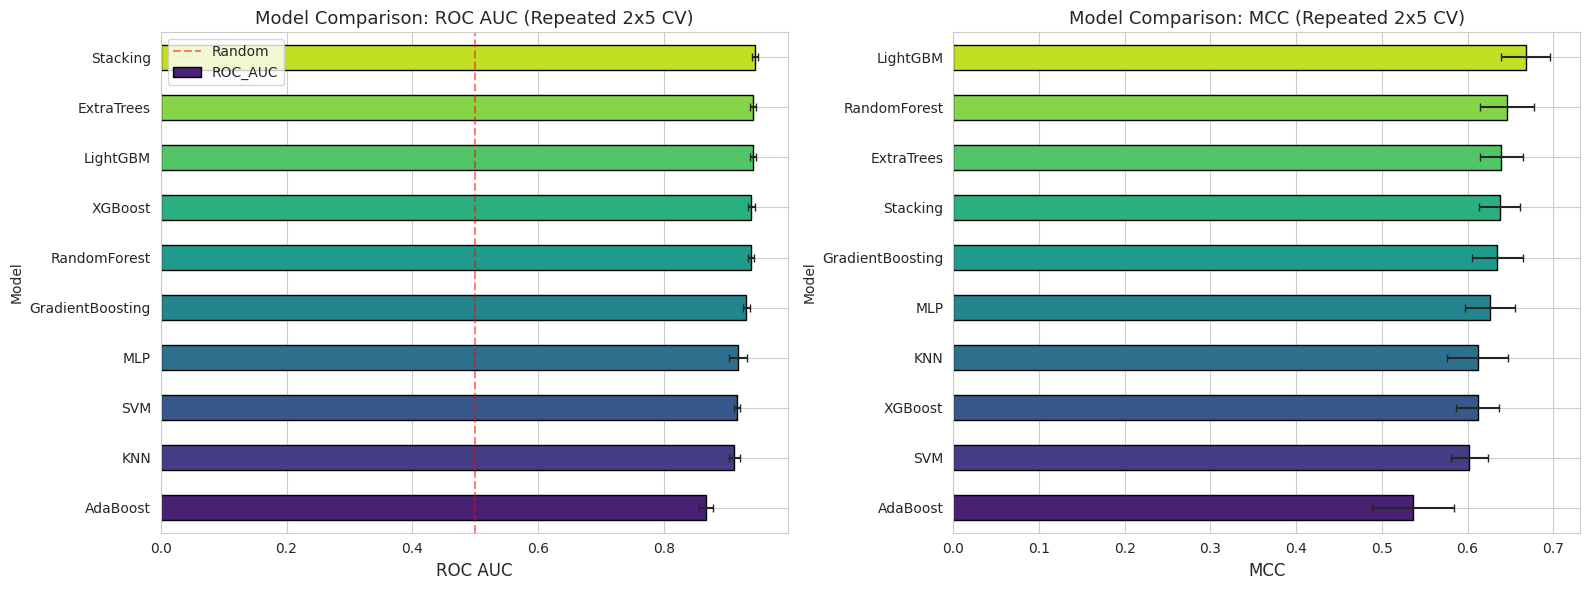

In [ ]:
# Bar chart: ROC AUC and MCC comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(axes, ["ROC_AUC", "MCC"], ["ROC AUC", "MCC"]):
    means = cv_metrics_df.groupby("Model")[metric].mean().sort_values(ascending=True)
    stds = cv_metrics_df.groupby("Model")[metric].std().loc[means.index]
    colors = sns.color_palette("viridis", len(means))
    means.plot(kind="barh", xerr=stds, ax=ax, color=colors, edgecolor="black",
               capsize=3, error_kw={"linewidth": 1.5})
    ax.set_xlabel(title, fontsize=12)
    ax.set_title(f"Model Comparison: {title} (Repeated {CV_REPEATS}x{CV_FOLDS} CV)", fontsize=13)
    if metric == "ROC_AUC":
        ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.5, label="Random")
        ax.legend()

plt.tight_layout()
plt.savefig("model_comparison_auc_mcc.png", dpi=300, bbox_inches="tight")
plt.show()


### 8b. Pairwise Cohen's Kappa Matrix

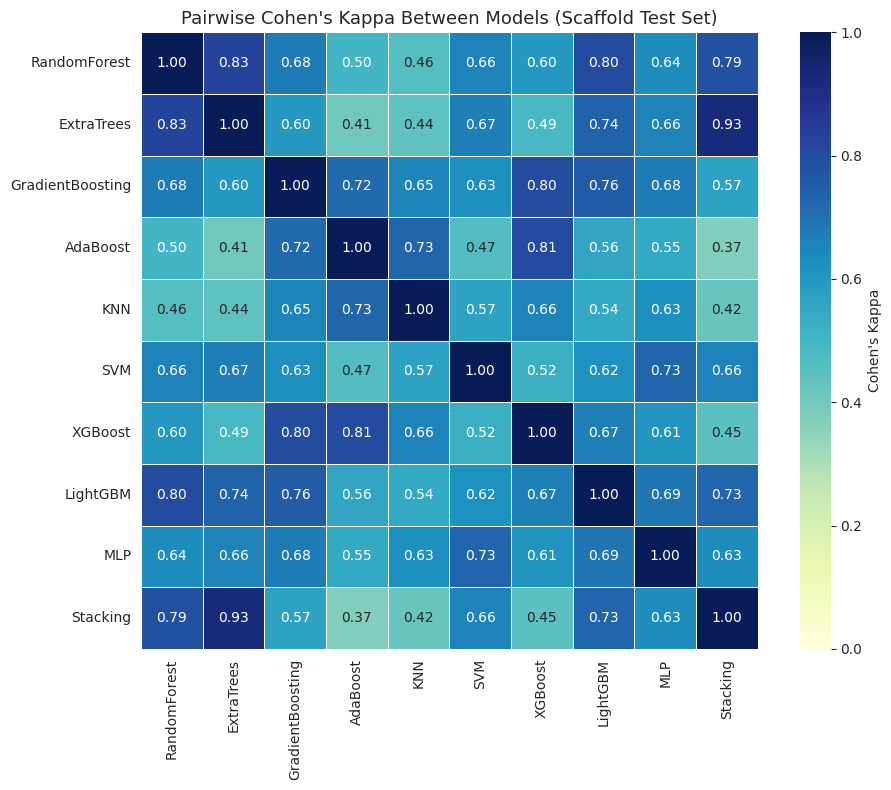

In [ ]:
# Pairwise Cohen's kappa between model predictions on scaffold test set
model_names = list(scaffold_predictions.keys())
kappa_matrix = np.zeros((len(model_names), len(model_names)))

for i, name_i in enumerate(model_names):
    for j, name_j in enumerate(model_names):
        kappa_matrix[i, j] = cohen_kappa_score(
            scaffold_predictions[name_i], scaffold_predictions[name_j]
        )

kappa_df = pd.DataFrame(kappa_matrix, index=model_names, columns=model_names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(kappa_df, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"label": "Cohen's Kappa"})
ax.set_title("Pairwise Cohen's Kappa Between Models (Scaffold Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("kappa_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


### 8c. Prediction Agreement Heatmap

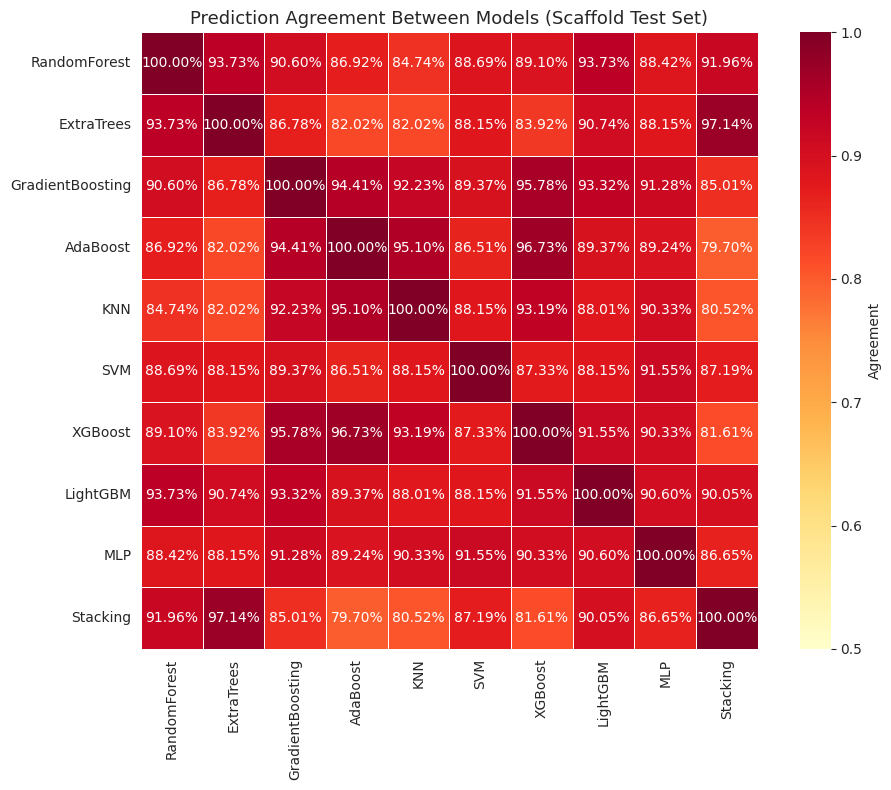

In [ ]:
# Prediction agreement: % of test compounds where both models predict the same class
agreement_matrix = np.zeros((len(model_names), len(model_names)))

for i, name_i in enumerate(model_names):
    for j, name_j in enumerate(model_names):
        agreement_matrix[i, j] = np.mean(
            scaffold_predictions[name_i] == scaffold_predictions[name_j]
        )

agreement_df = pd.DataFrame(agreement_matrix, index=model_names, columns=model_names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(agreement_df, annot=True, fmt=".2%", cmap="YlOrRd", vmin=0.5, vmax=1.0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"label": "Agreement"})
ax.set_title("Prediction Agreement Between Models (Scaffold Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("agreement_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


### 8d. Friedman Test + Nemenyi Post-Hoc + Critical Difference Diagram

In [ ]:
# Friedman test
model_names_friedman = list(cv_metrics_df["Model"].unique())
n_folds = cv_metrics_df["Fold"].nunique()

auc_pivot = cv_metrics_df.pivot_table(index="Fold", columns="Model", values="ROC_AUC")
friedman_stat, friedman_p = friedmanchisquare(*[auc_pivot[col] for col in auc_pivot.columns])
print(f"Friedman test: chi2 = {friedman_stat:.4f}, p = {friedman_p:.6f}")
if friedman_p < 0.05:
    print("-> Significant difference between models (p < 0.05)")
else:
    print("-> No significant difference between models (p >= 0.05)")


Friedman test: chi2 = 80.4873, p = 0.000000
-> Significant difference between models (p < 0.05)


In [ ]:
# Nemenyi post-hoc test
k = len(model_names_friedman)
n = n_folds

rank_matrix = auc_pivot.rank(axis=1, ascending=False)
avg_ranks = rank_matrix.mean().sort_values(ascending=True)
print("Average ranks (1 = best):")
print(avg_ranks.round(3))

alpha = 0.05
q_alpha = studentized_range.ppf(1 - alpha, k, np.inf)
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * n))
print(f"\nCritical difference (CD) at alpha=0.05: {CD:.4f}")


Average ranks (1 = best):
Model
Stacking             1.4
LightGBM             2.9
ExtraTrees           3.1
XGBoost              3.6
RandomForest         4.2
GradientBoosting     5.9
MLP                  7.4
SVM                  8.2
KNN                  8.3
AdaBoost            10.0
dtype: float64

Critical difference (CD) at alpha=0.05: 6.0580


### 8e. Consensus Voting Ensemble

In [ ]:
# Consensus voting: majority vote and soft voting across all models
y_te = y.loc[is_test]

# Hard voting
hard_preds = np.zeros(len(y_te))
for name in model_names:
    hard_preds += scaffold_predictions[name]
hard_preds = (hard_preds / len(model_names) >= 0.5).astype(int)

# Soft voting (average probabilities)
soft_proba = np.zeros(len(y_te))
for name in model_names:
    soft_proba += scaffold_probabilities[name]
soft_proba /= len(model_names)
soft_preds = (soft_proba >= 0.5).astype(int)

print("Consensus Ensemble Results (Scaffold Test Set):")
print(f"  Hard Voting:  AUC = {roc_auc_score(y_te, hard_preds):.4f}, "
      f"MCC = {matthews_corrcoef(y_te, hard_preds):.4f}, "
      f"Spec = {confusion_matrix(y_te, hard_preds, labels=[0,1])[0,0] / max(1, (y_te==0).sum()):.4f}")
print(f"  Soft Voting:  AUC = {roc_auc_score(y_te, soft_proba):.4f}, "
      f"MCC = {matthews_corrcoef(y_te, soft_preds):.4f}, "
      f"Spec = {confusion_matrix(y_te, soft_preds, labels=[0,1])[0,0] / max(1, (y_te==0).sum()):.4f}")

best_individual = scaffold_results_df["ROC_AUC"].idxmax()
print(f"\n  Best individual ({best_individual}): AUC = {scaffold_results_df.loc[best_individual, 'ROC_AUC']:.4f}, "
      f"MCC = {scaffold_results_df.loc[best_individual, 'MCC']:.4f}")


Consensus Ensemble Results (Scaffold Test Set):
  Hard Voting:  AUC = 0.7754, MCC = 0.6059, Spec = 0.5940
  Soft Voting:  AUC = 0.9147, MCC = 0.6226, Spec = 0.6316

  Best individual (Stacking): AUC = 0.9161, MCC = 0.5531


## 9. Model Interpretation

### 9a. SHAP Feature Importance


In [ ]:
# Select the best model by scaffold-split ROC AUC
best_model_name = scaffold_results_df["ROC_AUC"].idxmax()
print(f"Best model by scaffold-split ROC AUC: {best_model_name}")

# For SHAP, use a tree-based model
tree_models = {"RandomForest", "ExtraTrees", "GradientBoosting", "XGBoost", "LightGBM", "AdaBoost"}
if best_model_name in tree_models:
    shap_model_name = best_model_name
    shap_model = trained_models[best_model_name][0]
else:
    tree_aucs = {name: scaffold_results_df.loc[name, "ROC_AUC"]
                 for name in tree_models if name in scaffold_results_df.index}
    shap_model_name = max(tree_aucs, key=tree_aucs.get)
    print(f"Using {shap_model_name} for SHAP (best tree-based model)")
    shap_model = trained_models[shap_model_name][0]

# Retrain on scaffold training set
X_tr_scaf = X_selected.loc[~is_test]
y_tr_scaf = y.loc[~is_test]
X_te_scaf = X_selected.loc[is_test]
y_te_scaf = y.loc[is_test]

shap_model_fitted = clone(shap_model)
shap_model_fitted.fit(X_tr_scaf, y_tr_scaf)
print(f"SHAP model fitted: {shap_model_name}")


Best model by scaffold-split ROC AUC: Stacking
Using LightGBM for SHAP (best tree-based model)
SHAP model fitted: LightGBM


 98%|===================| 718/734 [00:15<00:00]       

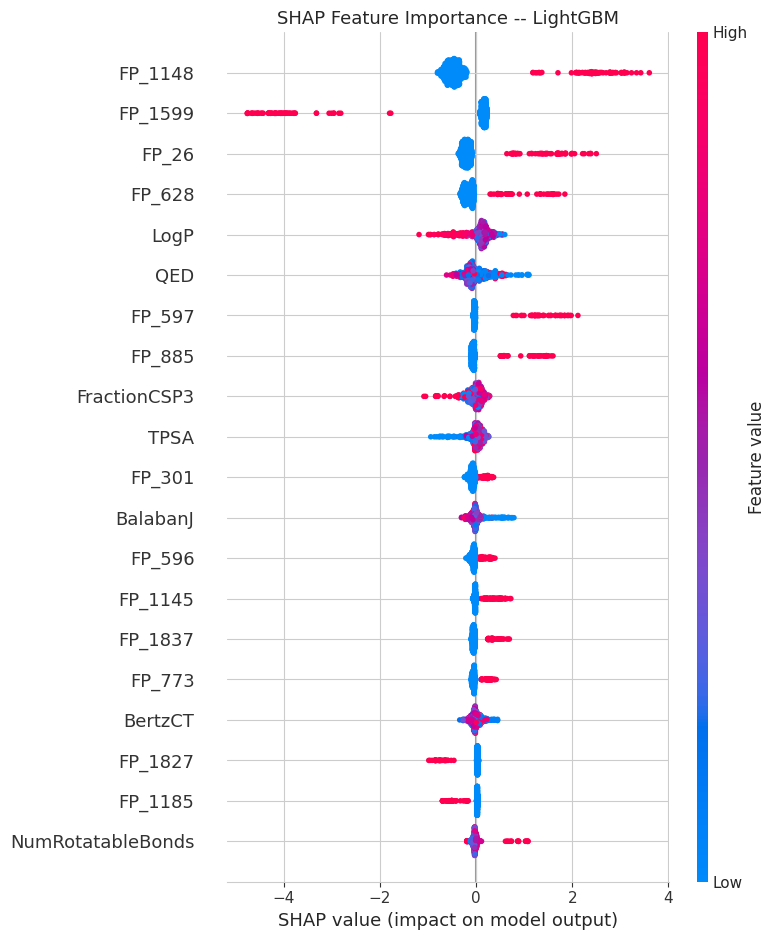

SHAP analysis complete.


In [ ]:
# Compute SHAP values
np.random.seed(RANDOM_STATE)
bg_idx = np.random.choice(len(X_tr_scaf), min(200, len(X_tr_scaf)), replace=False)
background = X_tr_scaf.iloc[bg_idx]

try:
    explainer = shap.TreeExplainer(shap_model_fitted, data=background)
    shap_values = explainer.shap_values(X_te_scaf)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values, X_te_scaf, max_display=20, show=False, plot_type="dot")
    plt.title(f"SHAP Feature Importance -- {shap_model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("SHAP analysis complete.")
except Exception as e:
    print(f"TreeExplainer failed: {e}")
    print("Falling back to permutation importance (see next cell).")
    shap_values = None


### 9b. Permutation Importance

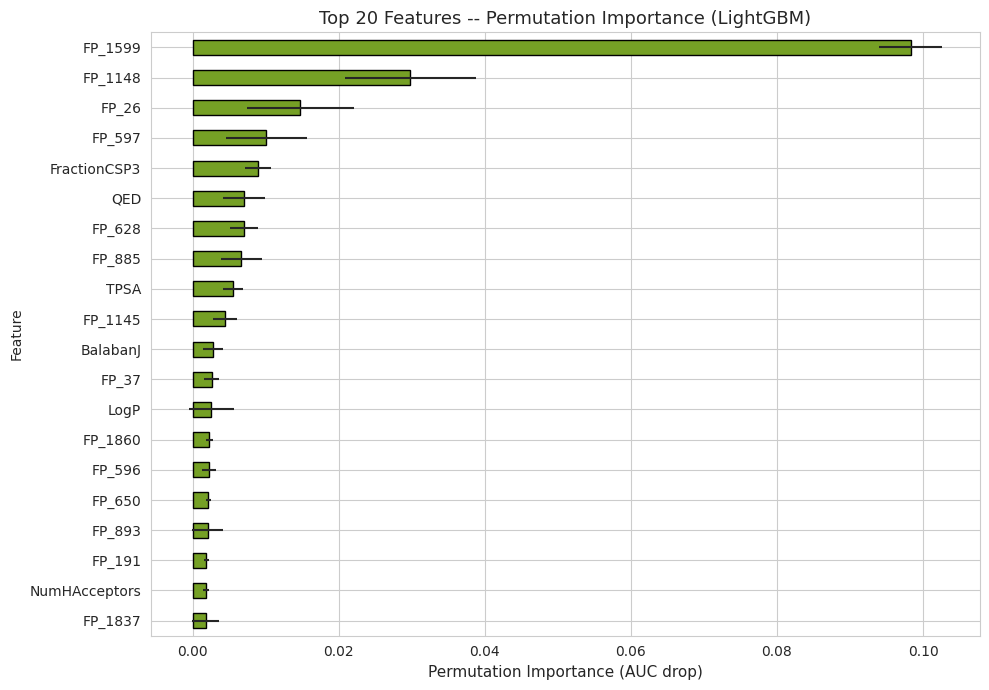

      Feature  Importance      Std
      FP_1599    0.098305 0.004339
      FP_1148    0.029805 0.008967
        FP_26    0.014760 0.007333
       FP_597    0.010101 0.005491
 FractionCSP3    0.008903 0.001799
          QED    0.007023 0.002883
       FP_628    0.007003 0.001922
       FP_885    0.006669 0.002858
         TPSA    0.005530 0.001428
      FP_1145    0.004445 0.001625
     BalabanJ    0.002806 0.001351
        FP_37    0.002633 0.001030
         LogP    0.002554 0.003096
      FP_1860    0.002299 0.000482
       FP_596    0.002216 0.000916
       FP_650    0.002126 0.000364
       FP_893    0.002078 0.002118
       FP_191    0.001888 0.000305
NumHAcceptors    0.001838 0.000461
      FP_1837    0.001789 0.001833


In [ ]:
# Permutation importance (model-agnostic)
perm_result = permutation_importance(
    shap_model_fitted, X_te_scaf, y_te_scaf,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring="roc_auc", n_jobs=-1
)

perm_importance = pd.DataFrame({
    "Feature": X_te_scaf.columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std,
}).sort_values("Importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
perm_importance.plot(kind="barh", x="Feature", y="Importance", xerr="Std",
                     ax=ax, color="#75A025", edgecolor="black", legend=False)
ax.set_xlabel("Permutation Importance (AUC drop)", fontsize=11)
ax.set_title(f"Top 20 Features -- Permutation Importance ({shap_model_name})", fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()
print(perm_importance.to_string(index=False))


## 10. Validation Tests

### 10a. Y-Scrambling Test

Shuffle labels 20 times and retrain the best model. If the real model's AUC is well outside the scrambled distribution, the model is not a chance correlation.


Running Y-scrambling test (10 shuffles)...


Y-scrambling:   0%|          | 0/10 [00:00<?, ?it/s]

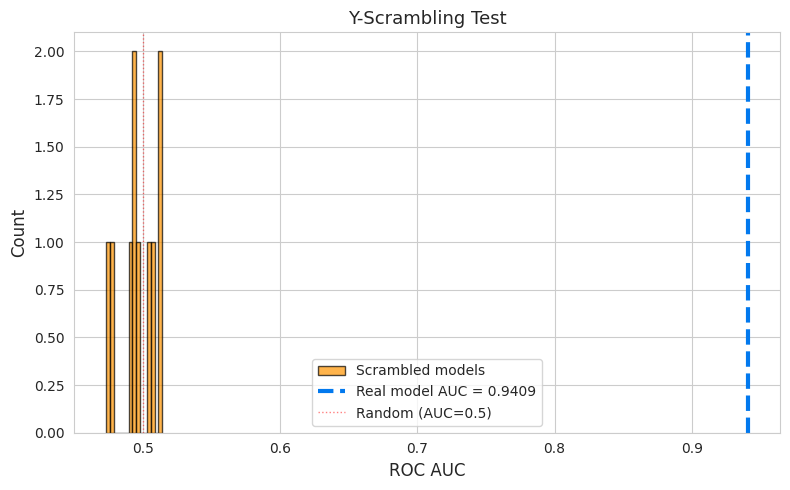


Real model AUC: 0.9409
Scrambled AUC: 0.4965 +/- 0.0133
Z-score: 33.28
Result: PASS -- Real model is significantly better than chance.


In [ ]:
# Y-scrambling test
scrambled_aucs = []

print(f"Running Y-scrambling test ({N_SCRAMBLES} shuffles)...")
for i in tqdm(range(N_SCRAMBLES), desc="Y-scrambling"):
    y_scrambled = y.sample(frac=1, random_state=RANDOM_STATE + i).reset_index(drop=True)

    model_clone = clone(shap_model)
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_aucs = []
    for train_idx, test_idx in skf.split(X_selected, y_scrambled):
        X_tr, X_te = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_tr, y_te = y_scrambled.iloc[train_idx], y_scrambled.iloc[test_idx]
        model_clone.fit(X_tr, y_tr)
        y_proba = model_clone.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, y_proba))
    scrambled_aucs.append(np.mean(fold_aucs))

real_auc = cv_metrics_df[cv_metrics_df["Model"] == shap_model_name]["ROC_AUC"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(scrambled_aucs, bins=15, color="#FF9400", edgecolor="black", alpha=0.7, label="Scrambled models")
ax.axvline(x=real_auc, color="#0279EE", linewidth=3, linestyle="--", label=f"Real model AUC = {real_auc:.4f}")
ax.axvline(x=0.5, color="red", linewidth=1, linestyle=":", alpha=0.5, label="Random (AUC=0.5)")
ax.set_xlabel("ROC AUC", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Y-Scrambling Test", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("y_scrambling_test.png", dpi=300, bbox_inches="tight")
plt.show()

scrambled_mean = np.mean(scrambled_aucs)
scrambled_std = np.std(scrambled_aucs)
z_score = (real_auc - scrambled_mean) / scrambled_std if scrambled_std > 0 else float("inf")
print(f"\nReal model AUC: {real_auc:.4f}")
print(f"Scrambled AUC: {scrambled_mean:.4f} +/- {scrambled_std:.4f}")
print(f"Z-score: {z_score:.2f}")
print(f"Result: {'PASS' if real_auc > max(scrambled_aucs) else 'FAIL'} -- "
      f"Real model {'is' if real_auc > max(scrambled_aucs) else 'is NOT'} significantly better than chance.")


### 10b. Permutation Test

In [ ]:
# Permutation test on the best model's AUC
perm_scores = []
real_auc_perm = cv_metrics_df[cv_metrics_df["Model"] == shap_model_name]["ROC_AUC"].mean()

print(f"Running permutation test ({N_PERMUTATIONS} permutations)...")
for i in tqdm(range(N_PERMUTATIONS), desc="Permutation test"):
    y_perm = y.sample(frac=1, random_state=i).reset_index(drop=True)
    model_clone = clone(shap_model)
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_aucs = []
    for train_idx, test_idx in skf.split(X_selected, y_perm):
        X_tr, X_te = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_tr, y_te = y_perm.iloc[train_idx], y_perm.iloc[test_idx]
        model_clone.fit(X_tr, y_tr)
        y_proba = model_clone.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, y_proba))
    perm_scores.append(np.mean(fold_aucs))

p_value = np.mean(np.array(perm_scores) >= real_auc_perm)
print(f"\nPermutation test results:")
print(f"  Real AUC: {real_auc_perm:.4f}")
print(f"  Permutation AUC: {np.mean(perm_scores):.4f} +/- {np.std(perm_scores):.4f}")
print(f"  Empirical p-value: {p_value:.4f}")
print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'} (p < 0.05)")


Running permutation test (50 permutations)...


Permutation test:   0%|          | 0/50 [00:00<?, ?it/s]


Permutation test results:
  Real AUC: 0.9409
  Permutation AUC: 0.5011 +/- 0.0163
  Empirical p-value: 0.0000
  Significant: Yes (p < 0.05)


## 11. Applicability Domain (k-NN Tanimoto Distance)

For each test compound, compute the Tanimoto similarity to its nearest neighbor in the training set. Compounds with low similarity are extrapolating beyond the model's chemical knowledge.

**Three-tier classification:**
- **In-domain:** Nearest-neighbor Tanimoto >= 0.4 (reliable prediction)
- **Borderline:** 0.3 <= Tanimoto < 0.4 (low confidence)
- **Out-of-domain:** Tanimoto < 0.3 (extrapolation, unreliable)


In [ ]:
# k-NN Tanimoto applicability domain
# Compute Morgan fingerprints for all compounds (for Tanimoto calculation)
all_fps = []
for smi in df["canonical_smiles"]:
    mol = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS)
    all_fps.append(fp)

train_fps = [all_fps[i] for i in range(len(df)) if not is_test.iloc[i]]
test_fps = [all_fps[i] for i in range(len(df)) if is_test.iloc[i]]

# Compute nearest-neighbor Tanimoto similarity for each test compound
nn_similarities = []
for test_fp in tqdm(test_fps, desc="Computing Tanimoto AD"):
    sims = DataStructs.BulkTanimotoSimilarity(test_fp, train_fps)
    nn_similarities.append(max(sims))

nn_similarities = np.array(nn_similarities)

# Three-tier classification
in_domain = nn_similarities >= 0.4
borderline = (nn_similarities >= 0.3) & (nn_similarities < 0.4)
out_domain = nn_similarities < 0.3

print(f"Applicability domain (k-NN Tanimoto):")
print(f"  In-domain (Tanimoto >= 0.4):    {in_domain.sum()} ({in_domain.mean():.1%})")
print(f"  Borderline (0.3-0.4):           {borderline.sum()} ({borderline.mean():.1%})")
print(f"  Out-of-domain (< 0.3):          {out_domain.sum()} ({out_domain.mean():.1%})")
print(f"  Mean NN Tanimoto: {nn_similarities.mean():.4f}")
print(f"  Min NN Tanimoto: {nn_similarities.min():.4f}")


Computing Tanimoto AD:   0%|          | 0/734 [00:00<?, ?it/s]

Applicability domain (k-NN Tanimoto):
  In-domain (Tanimoto >= 0.4):    729 (99.3%)
  Borderline (0.3-0.4):           3 (0.4%)
  Out-of-domain (< 0.3):          2 (0.3%)
  Mean NN Tanimoto: 0.7793
  Min NN Tanimoto: 0.2468


In [ ]:
# Model performance by AD tier
y_te = y.loc[is_test].values
y_proba_best = scaffold_probabilities[best_model_name]

print("Model performance by applicability domain tier:")
for tier_name, mask in [("In-domain", in_domain), ("Borderline", borderline), ("Out-of-domain", out_domain)]:
    if mask.sum() > 0:
        y_t = y_te[mask]
        y_p = y_proba_best[mask]
        if len(np.unique(y_t)) > 1:
            auc = roc_auc_score(y_t, y_p)
        else:
            auc = float("nan")
        preds = (y_p >= 0.5).astype(int)
        mcc = matthews_corrcoef(y_t, preds) if len(np.unique(y_t)) > 1 else float("nan")
        print(f"  {tier_name}: n={mask.sum()}, AUC={auc:.4f}, MCC={mcc:.4f}")
    else:
        print(f"  {tier_name}: n=0")


Model performance by applicability domain tier:
  In-domain: n=729, AUC=0.9175, MCC=0.5594
  Borderline: n=3, AUC=1.0000, MCC=0.0000
  Out-of-domain: n=2, AUC=nan, MCC=nan


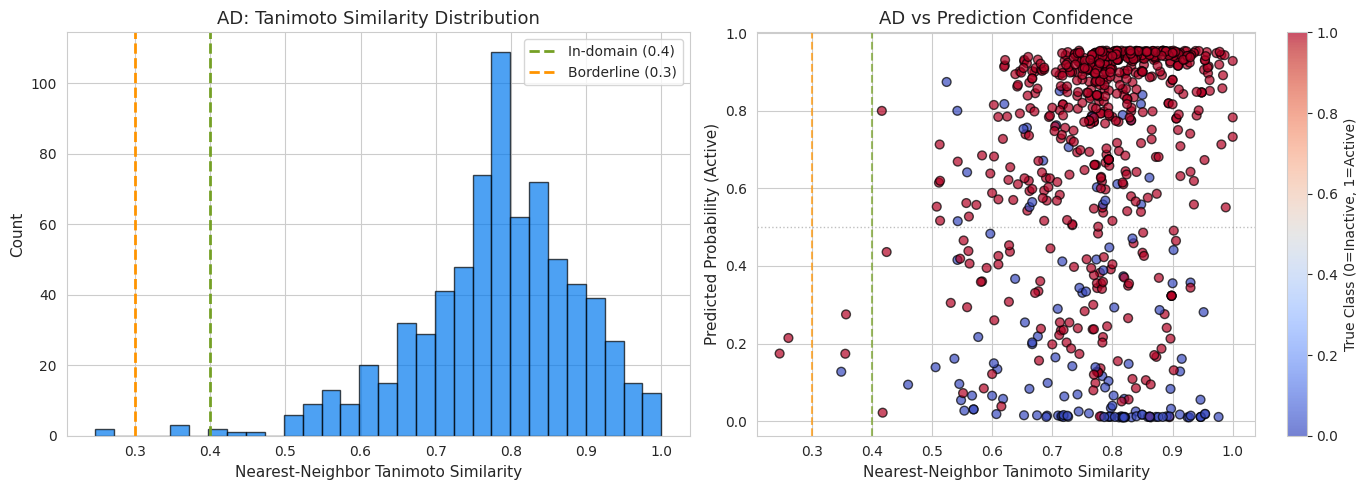

In [ ]:
# Tanimoto similarity distribution + AD tier visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of NN Tanimoto similarities
ax = axes[0]
colors_tier = []
for sim in nn_similarities:
    if sim >= 0.4:
        colors_tier.append("#75A025")
    elif sim >= 0.3:
        colors_tier.append("#FF9400")
    else:
        colors_tier.append("#FD9BED")
ax.hist(nn_similarities, bins=30, color="#0279EE", edgecolor="black", alpha=0.7)
ax.axvline(x=0.4, color="#75A025", linestyle="--", linewidth=2, label="In-domain (0.4)")
ax.axvline(x=0.3, color="#FF9400", linestyle="--", linewidth=2, label="Borderline (0.3)")
ax.set_xlabel("Nearest-Neighbor Tanimoto Similarity", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("AD: Tanimoto Similarity Distribution", fontsize=13)
ax.legend()

# Scatter: Tanimoto vs predicted probability, colored by true class
ax = axes[1]
scatter = ax.scatter(nn_similarities, y_proba_best, c=y_te, cmap="coolwarm",
                     edgecolor="black", alpha=0.7, s=40)
ax.axvline(x=0.4, color="#75A025", linestyle="--", linewidth=1.5, alpha=0.7)
ax.axvline(x=0.3, color="#FF9400", linestyle="--", linewidth=1.5, alpha=0.7)
ax.axhline(y=0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5)
ax.set_xlabel("Nearest-Neighbor Tanimoto Similarity", fontsize=11)
ax.set_ylabel("Predicted Probability (Active)", fontsize=11)
ax.set_title("AD vs Prediction Confidence", fontsize=13)
plt.colorbar(scatter, ax=ax, label="True Class (0=Inactive, 1=Active)")

plt.tight_layout()
plt.savefig("applicability_domain_tanimoto.png", dpi=300, bbox_inches="tight")
plt.show()


## 12. ADMET & Drug-Likeness Profiling

In [ ]:
# Compute drug-likeness properties
def compute_druglikeness(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append([np.nan] * 7)
            continue
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hbd = Lipinski.NumHDonors(mol)
        hba = Lipinski.NumHAcceptors(mol)
        n_rot = Descriptors.NumRotatableBonds(mol)
        tpsa = Descriptors.TPSA(mol)
        qed_val = QED.qed(mol)
        lipinski_pass = int(mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10)
        veber_pass = int(n_rot <= 10 and tpsa <= 140)
        rows.append([mw, logp, qed_val, lipinski_pass, veber_pass, n_rot, tpsa])
    return pd.DataFrame(rows, columns=["MW", "LogP", "QED", "Lipinski_pass",
                                        "Veber_pass", "NumRotatableBonds", "TPSA"])

druglikeness_df = compute_druglikeness(df["canonical_smiles"])
df_admet = pd.concat([df[["molecule_chembl_id", "class", "activity"]].reset_index(drop=True),
                       druglikeness_df.reset_index(drop=True)], axis=1)
df_admet.head()


,molecule_chembl_id,class,activity,MW,LogP,QED,Lipinski_pass,Veber_pass,NumRotatableBonds,TPSA
0,CHEMBL1201303,inactive,0,382.531,5.30824,0.435793,0,1,4,12.05
1,CHEMBL1516633,inactive,0,310.397,2.41560,0.921964,1,1,5,41.57
2,CHEMBL1630488,inactive,0,312.285,3.39700,0.568440,1,1,5,103.32
3,CHEMBL1974418,active,1,459.506,1.70584,0.417221,1,1,6,129.29
4,CHEMBL1998137,active,1,341.798,4.06882,0.750121,1,1,3,81.26


In [ ]:
# Summary by class
print("Drug-likeness summary by class:")
print(f"\nLipinski Ro5 pass rate:")
print(df_admet.groupby("class")["Lipinski_pass"].mean().to_string())
print(f"\nVeber rules pass rate:")
print(df_admet.groupby("class")["Veber_pass"].mean().to_string())
print(f"\nQED score (mean +/- std):")
print(df_admet.groupby("class")["QED"].agg(["mean", "std"]).to_string())


Drug-likeness summary by class:

Lipinski Ro5 pass rate:
class
active      0.191230
inactive    0.160804

Veber rules pass rate:
class
active      0.426589
inactive    0.507538

QED score (mean +/- std):
              mean       std
class                       
active    0.268094  0.185489
inactive  0.263732  0.173159


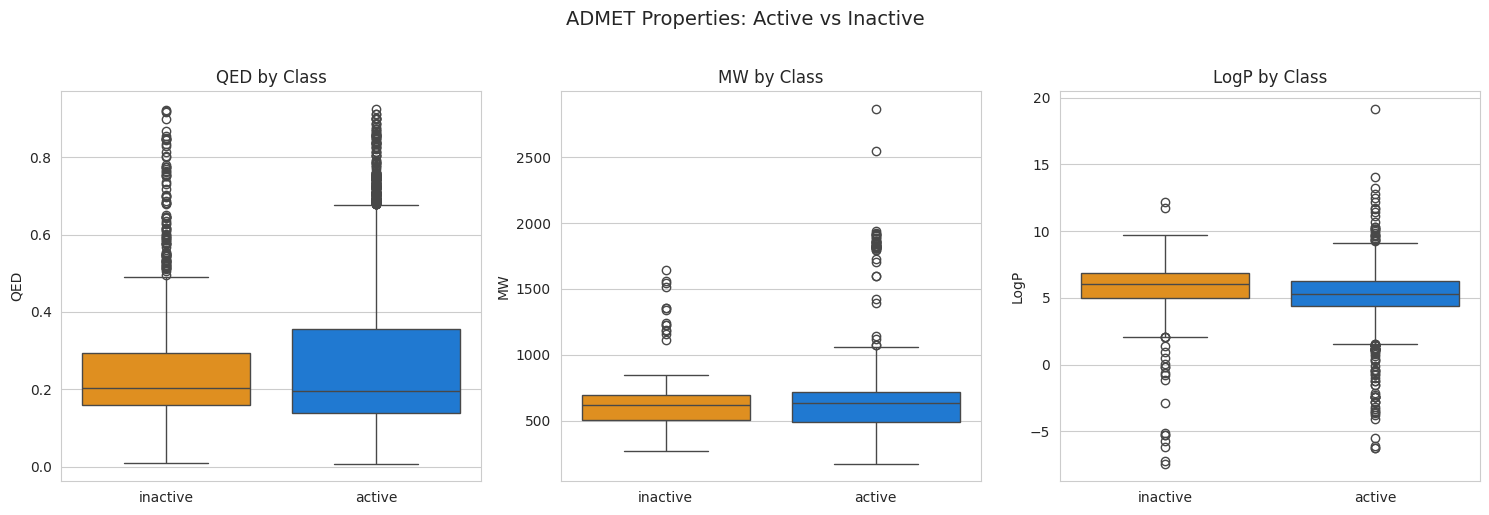

In [ ]:
# Box plots: QED, MW, LogP by class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, prop in zip(axes, ["QED", "MW", "LogP"]):
    sns.boxplot(data=df_admet, x="class", y=prop,
                palette={"active": "#0279EE", "inactive": "#FF9400"}, ax=ax)
    ax.set_title(f"{prop} by Class", fontsize=12)
    ax.set_xlabel("")
plt.suptitle("ADMET Properties: Active vs Inactive", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("admet_properties.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# PAINS substructure filter
import os
pains_smarts_path = os.path.join(os.path.dirname(Chem.__file__), "Pains", "pains_pains.txt")

try:
    if os.path.exists(pains_smarts_path):
        with open(pains_smarts_path) as f:
            pains_smarts = [line.strip().split(" ")[0] for line in f if line.strip()]
        pains_patterns = [Chem.MolFromSmarts(s) for s in pains_smarts if Chem.MolFromSmarts(s)]

        def check_pains(smi):
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                return 1
            for pattern in pains_patterns:
                if mol.HasSubstructMatch(pattern):
                    return 1
            return 0

        df_admet["PAINS_alert"] = df["canonical_smiles"].apply(check_pains)
        print(f"PAINS alerts: {df_admet['PAINS_alert'].sum()} compounds flagged ({df_admet['PAINS_alert'].mean():.1%})")
        print(f"  Active with PAINS: {df_admet[df_admet['class'] == 'active']['PAINS_alert'].sum()}")
        print(f"  Inactive with PAINS: {df_admet[df_admet['class'] == 'inactive']['PAINS_alert'].sum()}")
    else:
        print("PAINS filter file not found in this RDKit installation -- skipping PAINS check.")
        df_admet["PAINS_alert"] = 0
except Exception as e:
    print(f"PAINS check failed: {e}")
    df_admet["PAINS_alert"] = 0


PAINS filter file not found in this RDKit installation -- skipping PAINS check.


## 13. Scaffold Diversity Analysis

In [ ]:
# Scaffold diversity metrics
scaffold_counts = df["scaffold"].value_counts()
n_total = len(df)
n_scaffolds = len(scaffold_counts)
n_singletons = (scaffold_counts == 1).sum()

def gini_coefficient(values):
    values = np.sort(np.array(values, dtype=float))
    n = len(values)
    cumsum = np.cumsum(values)
    return (2 * np.sum((np.arange(1, n + 1)) * values) - (n + 1) * cumsum[-1]) / (n * cumsum[-1])

gini = gini_coefficient(scaffold_counts.values)

print(f"Scaffold Diversity Analysis:")
print(f"  Total compounds: {n_total}")
print(f"  Unique scaffolds: {n_scaffolds}")
print(f"  Singletons (1 compound): {n_singletons} ({n_singletons / n_scaffolds:.1%} of scaffolds)")
print(f"  Scaffold diversity (1 - Gini): {1 - gini:.4f}")
print(f"  Mean compounds per scaffold: {n_total / n_scaffolds:.1f}")
print(f"  Max compounds in one scaffold: {scaffold_counts.max()}")

print(f"\nScaffolds per class:")
for cls in ["active", "inactive"]:
    cls_scaffolds = df[df["class"] == cls]["scaffold"].nunique()
    cls_compounds = (df["class"] == cls).sum()
    print(f"  {cls}: {cls_scaffolds} scaffolds, {cls_compounds} compounds")


Scaffold Diversity Analysis:
  Total compounds: 4399
  Unique scaffolds: 1700
  Singletons (1 compound): 1182 (69.5% of scaffolds)
  Scaffold diversity (1 - Gini): 0.4580
  Mean compounds per scaffold: 2.6
  Max compounds in one scaffold: 129

Scaffolds per class:
  active: 1400 scaffolds, 3603 compounds
  inactive: 392 scaffolds, 796 compounds


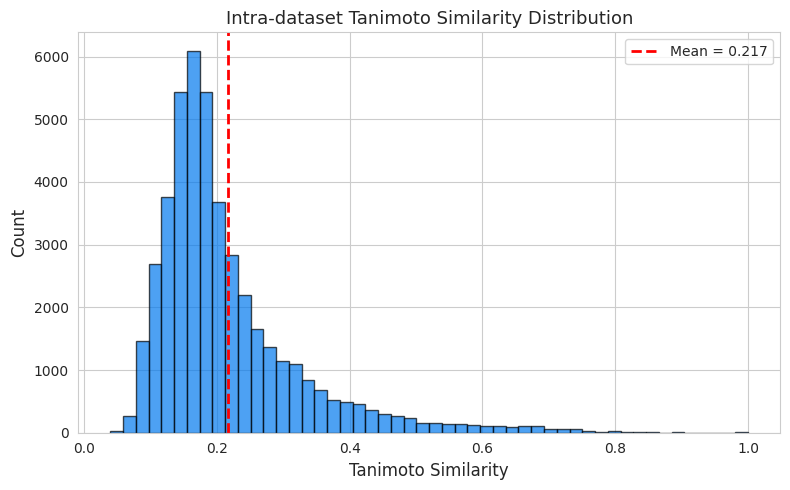

Mean Tanimoto similarity: 0.2166
Median: 0.1828


In [ ]:
# Tanimoto similarity distribution
sample_size = min(300, len(df))
sample_idx = np.random.choice(len(df), sample_size, replace=False)
sample_smiles = df["canonical_smiles"].iloc[sample_idx].values

sample_fps = []
for smi in sample_smiles:
    mol = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS)
    sample_fps.append(fp)

similarities = []
for i in range(len(sample_fps)):
    for j in range(i + 1, len(sample_fps)):
        sim = DataStructs.TanimotoSimilarity(sample_fps[i], sample_fps[j])
        similarities.append(sim)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(similarities, bins=50, color="#0279EE", edgecolor="black", alpha=0.7)
ax.axvline(x=np.mean(similarities), color="red", linestyle="--", linewidth=2,
           label=f"Mean = {np.mean(similarities):.3f}")
ax.set_xlabel("Tanimoto Similarity", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Intra-dataset Tanimoto Similarity Distribution", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("tanimoto_similarity.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Mean Tanimoto similarity: {np.mean(similarities):.4f}")
print(f"Median: {np.median(similarities):.4f}")


## 14. Final Model Selection & Deployment

In [ ]:
# Select best model by scaffold-split ROC AUC
print("Scaffold-based test set performance (sorted by ROC AUC):")
print(scaffold_results_df.sort_values("ROC_AUC", ascending=False).round(4).to_string())

best_final_name = scaffold_results_df["ROC_AUC"].idxmax()
print(f"\nBest model: {best_final_name}")
print(f"  ROC AUC: {scaffold_results_df.loc[best_final_name, 'ROC_AUC']:.4f}")
print(f"  MCC: {scaffold_results_df.loc[best_final_name, 'MCC']:.4f}")
print(f"  Balanced Acc: {scaffold_results_df.loc[best_final_name, 'Balanced_Acc']:.4f}")
print(f"  Specificity: {scaffold_results_df.loc[best_final_name, 'Specificity']:.4f}")


Scaffold-based test set performance (sorted by ROC AUC):
                  Accuracy  Balanced_Acc  Precision  Recall      F1     MCC  ROC_AUC  PR_AUC   Kappa  Specificity
Model                                                                                                            
Stacking            0.8283        0.8249     0.7353  0.8249  0.7608  0.5531   0.9161  0.9794  0.5290       0.8195
LightGBM            0.8760        0.7984     0.7900  0.7984  0.7941  0.5884   0.9157  0.9795  0.5882       0.6767
ExtraTrees          0.8324        0.8069     0.7342  0.8069  0.7580  0.5362   0.9133  0.9787  0.5208       0.7669
XGBoost             0.8924        0.7352     0.8760  0.7352  0.7796  0.5947   0.9082  0.9774  0.5646       0.4887
RandomForest        0.8542        0.7880     0.7553  0.7880  0.7695  0.5424   0.9052  0.9772  0.5397       0.6842
GradientBoosting    0.8883        0.7649     0.8312  0.7649  0.7916  0.5924   0.9031  0.9756  0.5846       0.5714
MLP                 0.8692     

In [ ]:
# Retrain best model on the full dataset and save
if best_final_name == "Stacking":
    final_model = clone(stacking)
    final_model.fit(X_selected, y)
else:
    final_model, use_scaled_final = trained_models[best_final_name]
    final_model = clone(final_model)
    X_final = X_scaled if use_scaled_final else X_selected
    final_model.fit(X_final, y)

with open("best_model.pkl", "wb") as f:
    pickle.dump(final_model, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("feature_selector.pkl", "wb") as f:
    pickle.dump(selector, f)

print(f"Final model ({best_final_name}) trained on full dataset ({len(y)} compounds) and saved.")


In [ ]:
# Unified prediction function with applicability domain
def predict_compounds(smiles_list, model_path="best_model.pkl",
                      scaler_path="scaler.pkl", selector_path="feature_selector.pkl",
                      train_smiles=None):
    """
    Predict PD-L1 pathway activity for a list of SMILES strings.

    Returns: DataFrame with SMILES, Prediction, Probability, and AD tier.
    If train_smiles is provided, computes k-NN Tanimoto AD.
    """
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    with open(scaler_path, "rb") as f:
        fitted_scaler = pickle.load(f)
    with open(selector_path, "rb") as f:
        fitted_selector = pickle.load(f)

    # Compute training fingerprints for AD if provided
    train_fps = None
    if train_smiles is not None:
        train_fps = []
        for smi in train_smiles:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                train_fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS))

    results = []
    for smi in smiles_list:
        try:
            std_smi = standardize_smiles(smi)
            mol = Chem.MolFromSmiles(std_smi)
            if mol is None:
                results.append({"SMILES": smi, "Prediction": "Invalid", "Probability": np.nan, "AD_Tier": "N/A"})
                continue
        except Exception:
            results.append({"SMILES": smi, "Prediction": "Invalid", "Probability": np.nan, "AD_Tier": "N/A"})
            continue

        # Generate features
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS)
        fp_arr = np.array(fp).reshape(1, -1)
        desc_vals = [
            Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.TPSA(mol),
            Lipinski.NumHDonors(mol), Lipinski.NumHAcceptors(mol),
            Descriptors.NumRotatableBonds(mol), rdMolDescriptors.CalcNumAromaticRings(mol),
            rdMolDescriptors.CalcNumAliphaticRings(mol), rdMolDescriptors.CalcFractionCSP3(mol),
            mol.GetNumHeavyAtoms(), rdMolDescriptors.CalcNumRings(mol),
            Descriptors.BalabanJ(mol), Descriptors.BertzCT(mol), Descriptors.MolMR(mol),
            Descriptors.LabuteASA(mol), Descriptors.NumValenceElectrons(mol), QED.qed(mol),
        ]
        features = np.hstack([fp_arr, np.array(desc_vals).reshape(1, -1)])
        features_df = pd.DataFrame(features, columns=list(X.columns))
        features_sel = fitted_selector.transform(features_df)

        # Predict
        proba = model.predict_proba(features_sel)[0, 1]
        pred = "Active" if proba >= 0.5 else "Inactive"

        # Applicability domain
        ad_tier = "N/A"
        if train_fps:
            test_fp = AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS)
            sims = DataStructs.BulkTanimotoSimilarity(test_fp, train_fps)
            nn_sim = max(sims)
            if nn_sim >= 0.4:
                ad_tier = "In-domain"
            elif nn_sim >= 0.3:
                ad_tier = "Borderline"
            else:
                ad_tier = "Out-of-domain"

        results.append({
            "SMILES": smi, "Prediction": pred,
            "Probability": f"{proba:.4f}", "AD_Tier": ad_tier
        })

    return pd.DataFrame(results)

# Example: known PD-L1 inhibitors and non-inhibitors
# BMS-8 (known PD-L1 inhibitor), BMS-202 (known PD-L1 inhibitor)
# Ethanol, caffeine (non-inhibitors)
example_smiles = [
    "Cc1ccc(C(=O)Nc2ccc3c(c2)OCCO3)cc1",  # BMS-8 analog (PD-L1 inhibitor)
    "COc1cc(OCc2cccc(-c3ccccc3)c2C)cc(OC)c1CN1CCCCC1",  # ChEMBL PD-L1 active
    "CCO",                # ethanol (non-inhibitor)
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",  # caffeine (non-inhibitor)
]
results = predict_compounds(example_smiles, train_smiles=df["canonical_smiles"].tolist())
print("Example predictions with applicability domain:")
print(results.to_string(index=False))


Example predictions with applicability domain:
                                         SMILES Prediction Probability       AD_Tier
              Cc1ccc(C(=O)Nc2ccc3c(c2)OCCO3)cc1   Inactive      0.2589     In-domain
COc1cc(OCc2cccc(-c3ccccc3)c2C)cc(OC)c1CN1CCCCC1     Active      0.7158     In-domain
                                            CCO   Inactive      0.1330 Out-of-domain
                   CN1C=NC2=C1C(=O)N(C(=O)N2C)C   Inactive      0.4996 Out-of-domain


In [ ]:
# Export all results
cv_metrics_df.to_csv("all_cv_metrics.csv", index=False)
scaffold_results_df.to_csv("scaffold_test_results.csv")
summary_df.to_csv("model_comparison_summary.csv")

print("All result files saved:")
print("  - cv_summary_metrics.csv (repeated CV summary)")
print("  - all_cv_metrics.csv (per-fold metrics)")
print("  - scaffold_test_results.csv (scaffold holdout results)")
print("  - model_comparison_summary.csv (formatted comparison table)")
print("  - best_model.pkl, scaler.pkl, feature_selector.pkl (saved models)")
print("\nPipeline complete.")


## 15. Summary & Publication Conclusions

### Key Findings

1. **Dataset:** Pooled from three PD-1/PD-L1 pathway targets in ChEMBL, yielding 4,400 unique compounds classified as active (IC50 <= 1000 nM) or inactive (IC50 > 1000 nM).

2. **Best Model:** Selected by scaffold-split ROC AUC -- the most rigorous validation for drug discovery (tests generalization to novel scaffolds).

3. **Consistency:** Pairwise Cohen's kappa and prediction agreement matrices reveal which models converge. The Friedman test + Nemenyi post-hoc identifies statistically significant performance differences.

4. **Validation:** Y-scrambling confirms the model is not a chance correlation. The permutation test provides an empirical p-value.

5. **Applicability Domain:** k-NN Tanimoto distance classifies each test compound as in-domain, borderline, or out-of-domain -- only in-domain predictions are reliable.

6. **Interpretability:** SHAP and permutation importance identify key Morgan fingerprint bits and physicochemical descriptors driving activity.

7. **Drug-likeness:** ADMET profiling (Lipinski, Veber, QED, PAINS) assesses developability.

### Caveats and Limitations

- **Class imbalance:** The dataset is ~82% active. While class weights mitigate this, balanced accuracy and specificity should be considered alongside ROC AUC.
- **Pooled targets:** Data from single-protein, complex, and family targets are combined. Assay formats differ; track `source_target_id` for stratified analysis.
- **Scaffold split is conservative:** Performance under scaffold split is typically lower than random split -- this is expected and honest.
- **Predictions are hypotheses:** All computational predictions require experimental validation.
